Search is a foundation of artificial intelligence: an agent has a current state, a set of legal actions, a goal test, and a cost. The algorithm decides which possible state to explore next.

## Learning goals

You will represent a grid as an implicit graph, implement breadth-first search, add a heuristic to obtain A*, reconstruct a solution path, and compare how much of the state space each strategy explores.

## Model the problem before choosing the algorithm

For our grid world:

- **State:** a `(row, column)` position.
- **Actions:** move up, down, left, or right.
- **Transition:** apply a legal move to reach a neighboring cell.
- **Step cost:** one per move.
- **Goal test:** current position equals the goal.

The graph does not need to be stored explicitly. A `neighbors` function can generate its edges when needed.

In [1]:
from collections import deque
from heapq import heappop, heappush
import numpy as np
import matplotlib.pyplot as plt

height, width = 12, 16
start, goal = (1, 1), (10, 14)
obstacles = (
    {(row, 5) for row in range(0, 9) if row != 4}
    | {(row, 10) for row in range(3, 12) if row != 8}
    | {(6, col) for col in range(6, 10)}
)

def neighbors(state):
    row, col = state
    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        candidate = (row + dr, col + dc)
        inside = 0 <= candidate[0] < height and 0 <= candidate[1] < width
        if inside and candidate not in obstacles:
            yield candidate

print(f"states in rectangle: {height * width}; blocked: {len(obstacles)}")

states in rectangle: 192; blocked: 20


## 1. Breadth-first search: expand by depth

A queue makes breadth-first search expand every state at distance 0, then distance 1, then distance 2. With equal step costs, the first path it finds is shortest. `came_from` prevents repeated work and stores enough information to reconstruct the path.

In [2]:
def reconstruct(came_from, goal):
    if goal not in came_from:
        return None
    path = [goal]
    while came_from[path[-1]] is not None:
        path.append(came_from[path[-1]])
    return list(reversed(path))

def breadth_first_search(start, goal):
    frontier = deque([start])
    came_from = {start: None}
    expansion_order = []

    while frontier:
        current = frontier.popleft()
        expansion_order.append(current)
        if current == goal:
            break
        for next_state in neighbors(current):
            if next_state not in came_from:
                came_from[next_state] = current
                frontier.append(next_state)

    return reconstruct(came_from, goal), expansion_order

bfs_path, bfs_expanded = breadth_first_search(start, goal)
print(f"BFS path length: {len(bfs_path) - 1}; states expanded: {len(bfs_expanded)}")

BFS path length: 24; states expanded: 168


## 2. A*: combine known cost with estimated remaining cost

A* prioritizes the smallest

$$f(n) = g(n) + h(n),$$

where $g(n)$ is the cost already paid and $h(n)$ estimates cost to the goal. Manhattan distance—row difference plus column difference—never overestimates the shortest four-directional grid path, so it is an admissible heuristic here.

In [3]:
def manhattan(state, goal):
    return abs(state[0] - goal[0]) + abs(state[1] - goal[1])

def a_star_search(start, goal, heuristic=manhattan):
    frontier = [(heuristic(start, goal), 0, start)]
    came_from = {start: None}
    cost_so_far = {start: 0}
    expansion_order = []

    while frontier:
        _, queued_cost, current = heappop(frontier)
        if queued_cost != cost_so_far[current]:
            continue
        expansion_order.append(current)
        if current == goal:
            break

        for next_state in neighbors(current):
            new_cost = cost_so_far[current] + 1
            if next_state not in cost_so_far or new_cost < cost_so_far[next_state]:
                cost_so_far[next_state] = new_cost
                priority = new_cost + heuristic(next_state, goal)
                heappush(frontier, (priority, new_cost, next_state))
                came_from[next_state] = current

    return reconstruct(came_from, goal), expansion_order

astar_path, astar_expanded = a_star_search(start, goal)
print(f"A* path length: {len(astar_path) - 1}; states expanded: {len(astar_expanded)}")
assert len(astar_path) == len(bfs_path)

A* path length: 24; states expanded: 103


## 3. See the difference in search effort

Both algorithms find a shortest path. The useful comparison is how many irrelevant states they had to expand first.

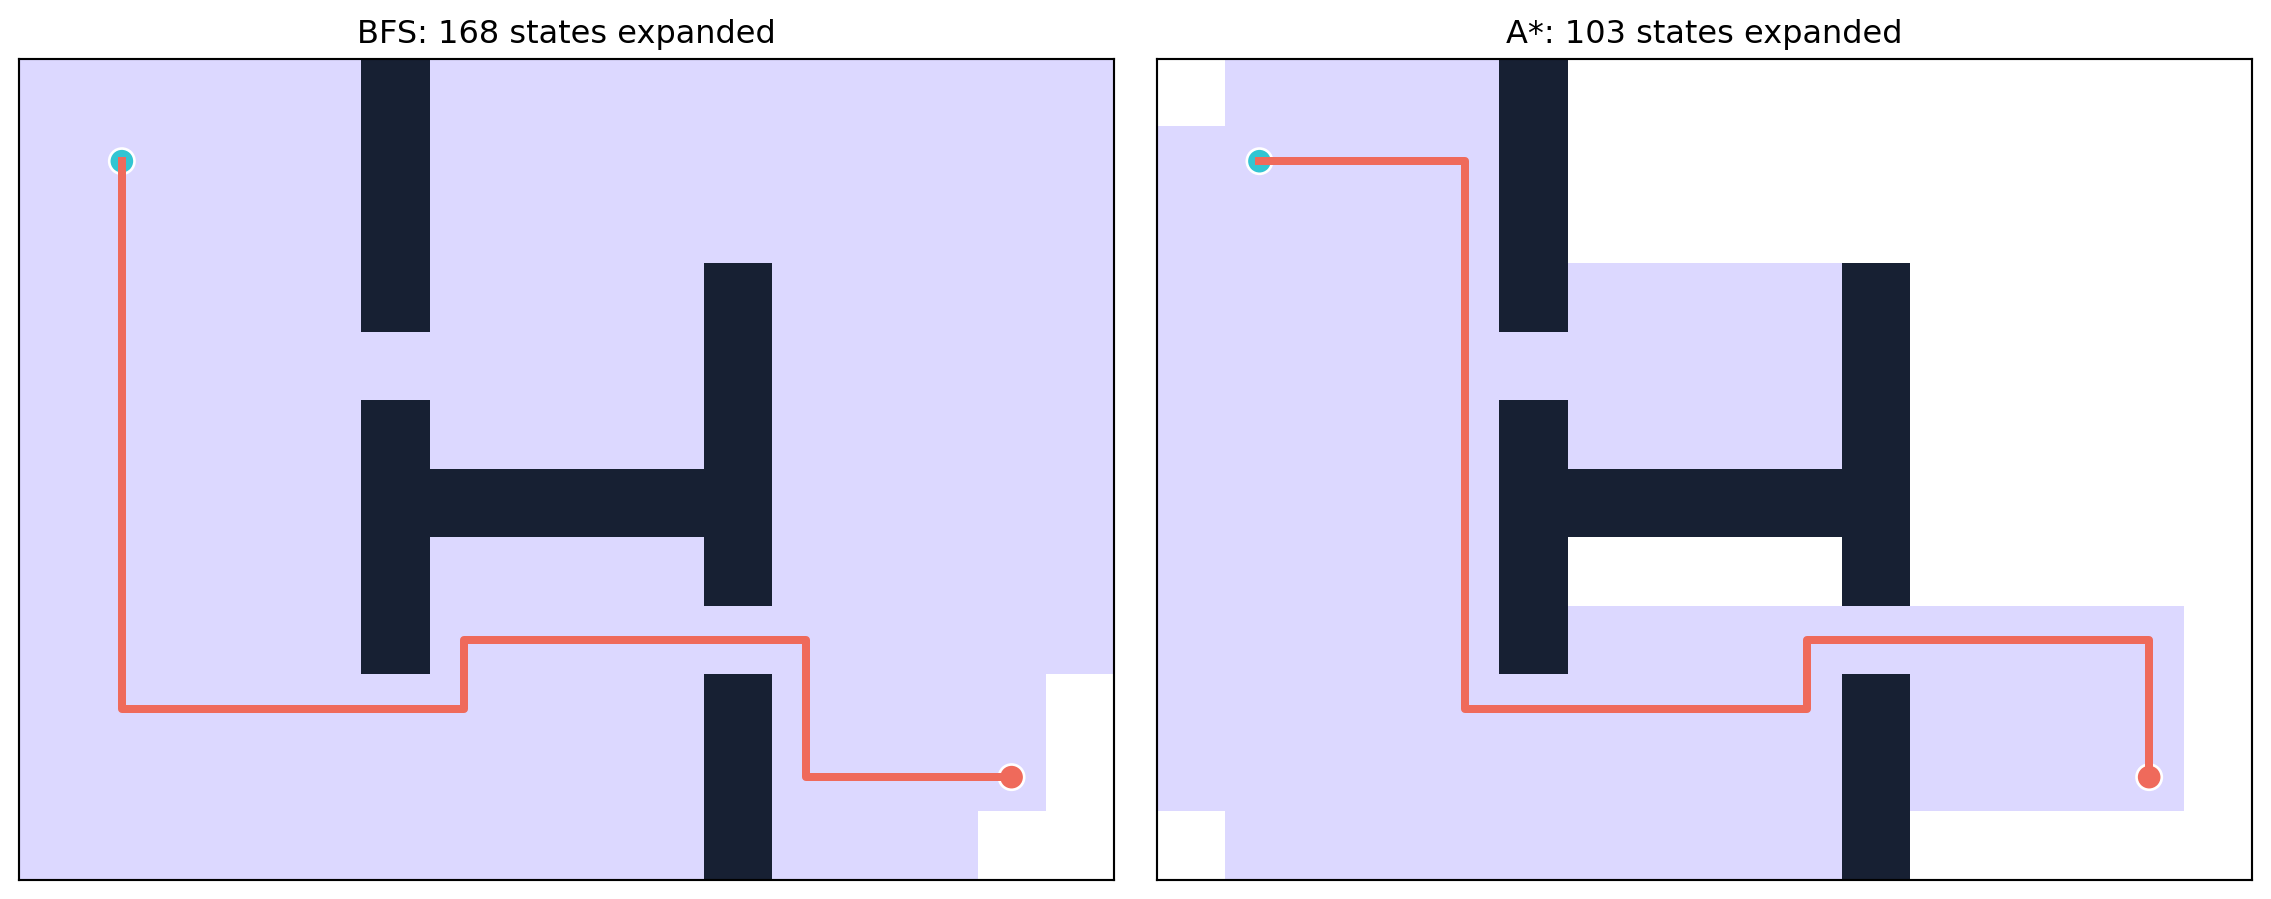

In [4]:
def draw_search(path, expanded, title, ax):
    canvas = np.zeros((height, width))
    for row, col in expanded:
        canvas[row, col] = 1
    for row, col in obstacles:
        canvas[row, col] = 2
    ax.imshow(canvas, cmap=plt.matplotlib.colors.ListedColormap(["#ffffff", "#dcd8ff", "#172033"]), vmin=0, vmax=2)
    path_rows, path_cols = zip(*path)
    ax.plot(path_cols, path_rows, color="#ef6a5b", linewidth=3)
    ax.scatter([start[1], goal[1]], [start[0], goal[0]], s=90, color=["#32c5d2", "#ef6a5b"], edgecolor="white")
    ax.set(title=title, xticks=[], yticks=[])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
draw_search(bfs_path, bfs_expanded, f"BFS: {len(bfs_expanded)} states expanded", axes[0])
draw_search(astar_path, astar_expanded, f"A*: {len(astar_expanded)} states expanded", axes[1])
plt.tight_layout()
plt.show()

## What makes a heuristic useful?

- `h(n) = 0` makes A* behave like uniform-cost search.
- A more informed admissible heuristic usually expands fewer states.
- An overestimating heuristic may be faster but can lose the shortest-path guarantee.
- A heuristic that is expensive to calculate can cost more than it saves.

Search quality therefore includes solution cost, memory use, expansions, and heuristic cost—not just whether a path exists.

## Try it yourself

1. Replace Manhattan distance with `0` and verify that A* expands more states.
2. Add weighted terrain where some cells cost 5 instead of 1; update both `g` and the comparison baseline.
3. Construct a deliberately overestimating heuristic and find a world where it returns a worse path.

Next: **[A neural network from scratch](neural-network-from-scratch.html)**.